In [39]:
import pandas as pd
import sqlite3
connection = sqlite3.connect('../../data/checking-logs.sqlite')

In [40]:
df = pd.io.sql.read_sql('''WITH views AS (SELECT DATE(datetime) AS date, COUNT (*) AS views
FROM pageviews
WHERE uid LIKE 'user%'
GROUP BY DATE(datetime)),
commits AS (SELECT DATE(timestamp) AS date, COUNT (*) AS commits
FROM checker
WHERE uid LIKE 'user%'
GROUP BY DATE(timestamp))
SELECT views.date, views.views, commits.commits
FROM views
JOIN commits ON views.date = commits.date;
''', connection)
df

,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28
5,2020-04-23,5,43
6,2020-04-25,1,104
7,2020-04-26,8,261
8,2020-04-28,2,5
9,2020-04-29,4,17


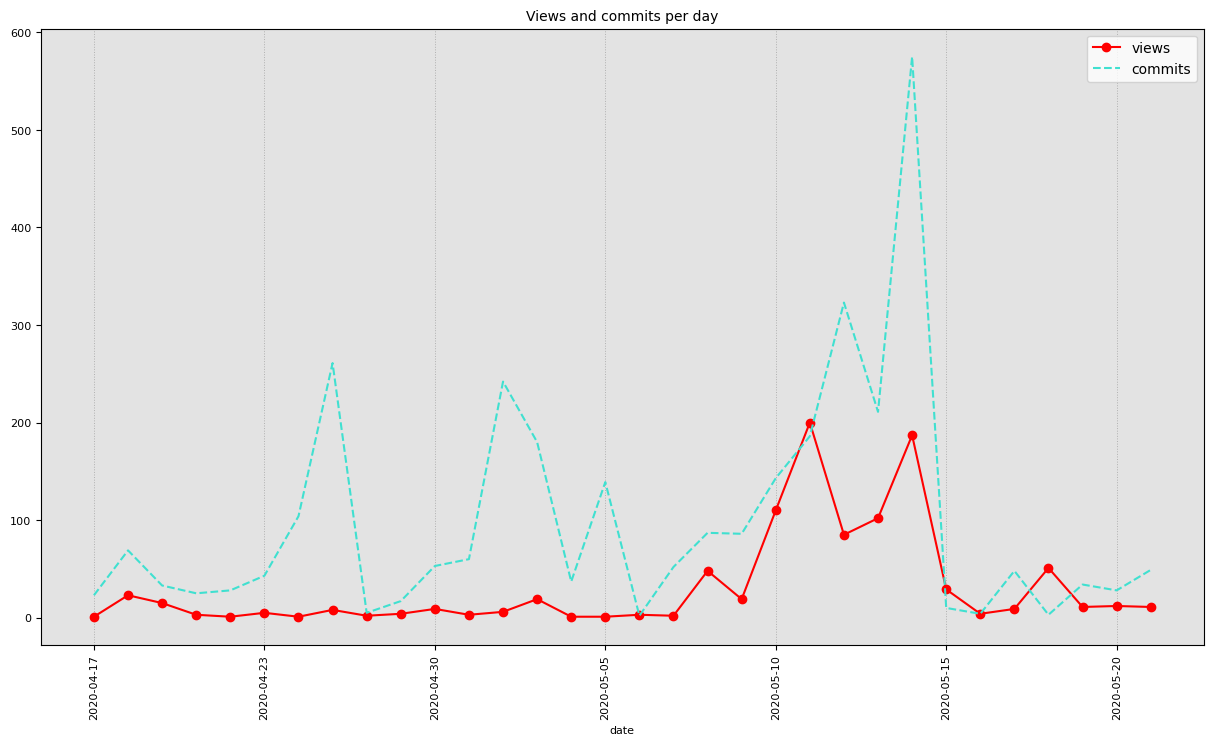

In [41]:
ax = df.plot(
    x="date",
    y="views",
    color="red",
    figsize=(15, 8),
    fontsize=8,
    style="o-",
    label="views"
)
df.plot(
    x="date",
    y="commits",
    label="commits",
    color="turquoise",
    ax=ax,
    linestyle="--"
)
ax.set_title("Views and commits per day", fontsize=10)
ax.set_xlabel("date", fontsize=8)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="x", linestyle=":", linewidth=0.7)
ax.set_facecolor("#E3E3E3")

## “How many times was the number of views larger than 150?”

In [ ]:
df.loc[df['views'] > 150]

,date,views,commits
21,2020-05-11,200,186
24,2020-05-14,187,575


The answer is 2.

In [43]:
connection.close()